In [21]:
import gpflow as gpf 
import numpy as np
import scipy.stats as ss
from tslearn.metrics import dtw

import matplotlib.pyplot as plt 
import tqdm as tqdm
import os

import sys
sys.path.append("../..")

from atmodel import ConditionalMOGP, SparseCMOGP
from atlikelihood import TransferLikelihood

# Data loading
If you want to download some other time range, remove the file volatility_data.npz, adjust the range below, and run the cell. The problem is that if you do too many requests to yfinance, it at some point will think you are a bot and stop giving you data.
The current range does not include a huge outlier in about 2020, so this should be pretty """"normal"""" data. 

In [22]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def standardize(s, mu=None, std=None):
    if not mu and not std:
        return (s - np.nanmean(s)) / np.nanstd(s)
    else:
        return (s - mu) / std

if not os.path.isfile("volatility_data.npz"):
    amzn = yf.download('AMZN', start='2021-01-01', end='2024-01-01')
    vix = yf.download('^VIX', start='2021-01-01', end='2024-07-01')
    amzn_test = yf.download('AMZN', start='2024-01-01', end='2024-07-01')

    amzn_monthly = amzn['Close'].resample('M').last()
    vix_weekly = vix['Close'].resample('W').last().interpolate("cubicspline")
    amzn_monthly_test = amzn_test['Close'].resample('M').last()

    amzn_monthly_returns = np.nan_to_num(amzn_monthly.values, 0)
    amzn_monthly_test_returns = np.nan_to_num(amzn_monthly_test.values, 0)
    vix_weekly_vals = vix_weekly.values

    Bx = amzn_monthly.index.view("int64").reshape(-1, 1).astype(float)
    Xtest = amzn_monthly_test.index.view("int64").reshape(-1, 1).astype(float)
    Ax = vix_weekly.index.view("int64").reshape(-1, 1).astype(float)
    Xtest = (Xtest - Bx.min()) /(Bx.max() - Bx.min())
    Ax = (Ax - Bx.min()) /(Bx.max() - Bx.min())
    Bx = (Bx - Bx.min()) /(Bx.max() - Bx.min())
    By = standardize(amzn_monthly_returns).reshape(-1, 1)
    Ay = standardize(vix_weekly_vals).reshape(-1, 1)
    ytest = standardize(amzn_monthly_test_returns, mu=np.nanmean(amzn_monthly_returns), std=np.nanstd(amzn_monthly_returns)).reshape(-1, 1)

    X = np.vstack((np.hstack((Ax, np.zeros_like(Ax))), np.hstack((Bx, np.ones_like(Bx)))))
    y = np.vstack((np.hstack((Ay, np.zeros_like(Ay))), np.hstack((By, np.ones_like(By)))))
    Xtest = np.hstack((Xtest, np.ones_like(Xtest)))

    np.savez(file="volatility_data.npz", X=X, y=y, Xtest=Xtest, ytest=ytest)

    print(len(Ax), len(Ay), len(Bx), len(By))
    print(Bx, By)
else:
    data = np.load("volatility_data.npz")
    X = data["X"]
    y = data["y"]
    Xtest = data["Xtest"]
    ytest = data["ytest"]
    Ax = X[X[:,1] == 0]
    Bx = X[X[:,1] == 1] 
    Ay = y[y[:,1] == 0]
    By = y[y[:,1] == 1]
    print(len(Ax) ,len(Bx))

182 36


In [23]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(8, 4))
    Xtest = np.linspace(0, 1, 100)[:, None]
    plt.plot(Ax, Ay, "x", color="C0", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, "C0", "Y1")

    plt.plot(Bx, By, "x",color="C1", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, "C1", "Y2")
    try:
        ivs = m.inducing_variable.Z.numpy() 
        plt.scatter(ivs, np.zeros_like(ivs)+2, marker="|", c=m.inducing_indices, cmap="plasma")
        plt.colorbar()
    except AttributeError:
        pass
    plt.xlim([0, max(X[:,0])])
    plt.legend()
    return mu


def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()
 

# Plot data

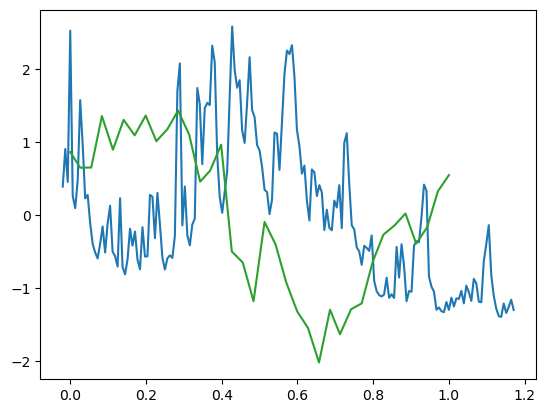

In [24]:
plt.plot(Ax, Ay)
plt.plot(Bx, By)

# Conditional MOGP

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ ConditionalMOGP.ke

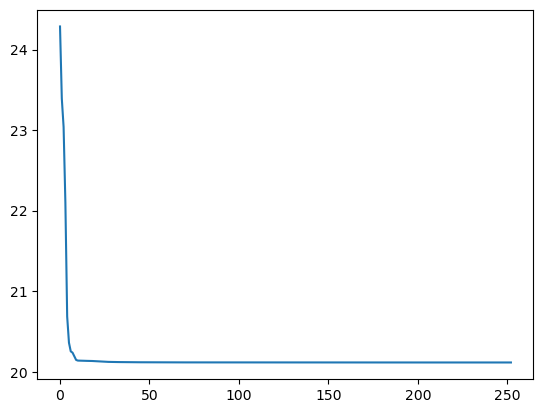

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                   │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.1010063304735698      │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.35311713681469453     │
├────────────────────────────────────────────────────┼──────────

In [25]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern12(active_dims=[0]) # Matern12 is much better for some reason.
k2 = gpf.kernels.Matern32(active_dims=[0]) # Matern12 is much better for some reason.
# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
coreg2 = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

# Initialize equal amounts of IVs for both datasets.
ivs = np.linspace(0, max(X[:,0]), 20).reshape(-1, 1)
iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))

kern = k * coreg
m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)



TensorShape([218, 100])
TensorShape([218, 100])
TensorShape([218, 6])


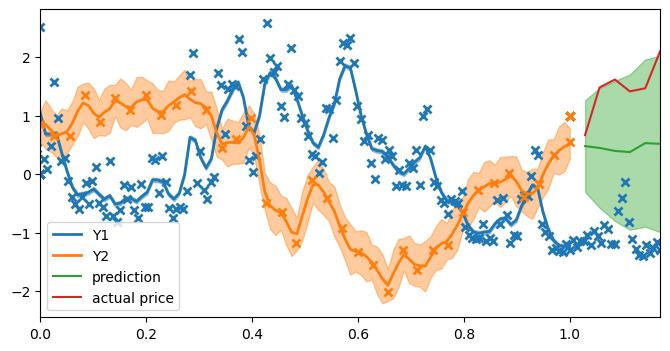

1.177721938253357


In [26]:
plot(m)
mu, var = m.predict_f(Xtest)
plt.plot(Xtest[:,0], mu, label="prediction", color="C2")
plt.plot(Xtest[:,0], ytest, label="actual price", color="C3")

plt.fill_between(
        Xtest[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))


# Sparse CMOGP

Results vary quite a lot dependent on (final) inducing point placement (which is to be expected). If they happen to end up in the test data area, we do pretty well, else, we do not.

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value           │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.0             │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.0             │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼────

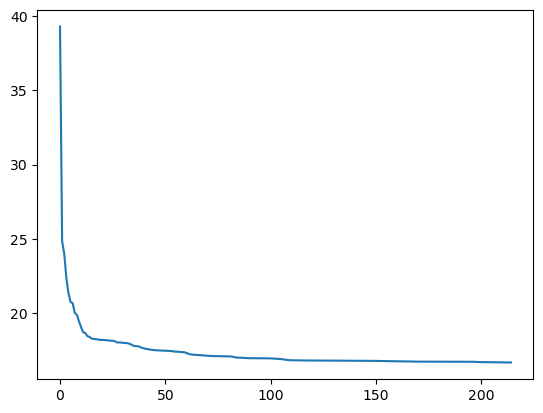

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤══════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value                │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪══════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.03088              │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼──────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 0.8109289020032687   │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────

In [27]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern12(active_dims=[0])  # Data pretty jagged, so use Matern.
k2 = gpf.kernels.Matern32(active_dims=[0])
# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
coreg2 = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
ivs = np.linspace(0, max(X[:,0]), 100).reshape(-1, 1)
iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg 
m = SparseCMOGP((X, y), exact_target=False, jitter=1e-5, kernel=kern, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.inducing_variable.Z, False)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

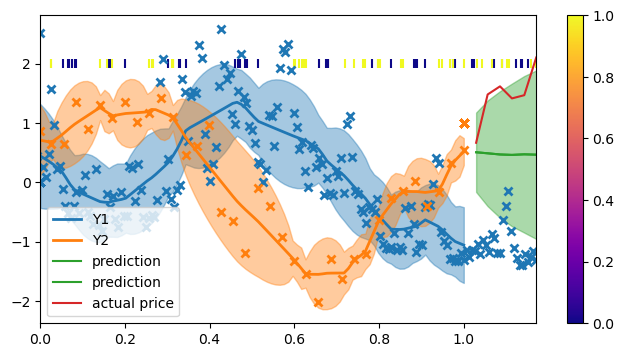

1.1508883224452582


In [28]:
plot(m)
mu, var = m.predict_f(Xtest)
mu2, var = m.expensive_predict_f(Xtest)
plt.plot(Xtest[:,0], mu, label="prediction", color="C2")
plt.plot(Xtest[:,0], mu2, label="prediction", color="C2")
plt.plot(Xtest[:,0], ytest, label="actual price", color="C3")

plt.fill_between(
        Xtest[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))


# Sparse VGP
This is technically not valid to do, since there is no way in GPFlow to fix the indices of the Coregion kernel while optimizing a sparse model. 

In [29]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
from robust_svgp import LMCInducingPointsBase
k = gpf.kernels.Matern12(active_dims=[0])
# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
coreg2 = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
ivs = np.linspace(0, max(X[:,0]), 100).reshape(-1, 1)
iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = LMCInducingPointsBase(np.hstack((ivs, iv_ind)))
kern = k * coreg

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)
# now build the GP model as normal
m = gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=ivs)

# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss_closure((X, y)),
    m.trainable_variables,
    method="L-BFGS-B",
)
gpf.utilities.print_summary(m)

2026-08-13 12:45:47.844976: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-08-13 12:45:48.259916: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═══════════════╤═════════╤══════════════════════════════════════════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape         │ dtype   │ value                                                │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═══════════════╪═════════╪══════════════════════════════════════════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 0.4032422655223376                                   │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼──────────────────────────────────────────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ (

tf.Tensor(
[[1.147395   0.        ]
 [0.40217969 0.        ]
 [0.6505848  0.        ]
 [0.8161882  0.        ]
 [0.17743222 0.        ]
 [0.23657629 0.        ]
 [0.80435938 0.        ]
 [0.28389155 0.        ]
 [1.08825093 0.        ]
 [0.91081871 0.        ]
 [0.83984583 0.        ]
 [0.78070175 0.        ]
 [0.36669325 0.        ]
 [0.31937799 0.        ]
 [1.10007974 0.        ]
 [0.72155768 0.        ]
 [0.52046784 0.        ]
 [0.96996279 0.        ]
 [0.67424242 0.        ]
 [0.20108985 0.        ]
 [0.1656034  0.        ]
 [1.02910686 0.        ]
 [0.11828814 0.        ]
 [0.03548644 0.        ]
 [0.09463052 0.        ]
 [0.0828017  0.        ]
 [0.82801701 0.        ]
 [0.14194577 0.        ]
 [0.57961191 0.        ]
 [1.01727804 0.        ]
 [0.9817916  0.        ]
 [0.10645933 0.        ]
 [1.11190856 0.        ]
 [1.07642212 0.        ]
 [0.35486443 0.        ]
 [0.88716108 0.        ]
 [1.17105263 0.        ]
 [0.34303562 0.        ]
 [0.3312068  0.        ]
 [0.44949495 0

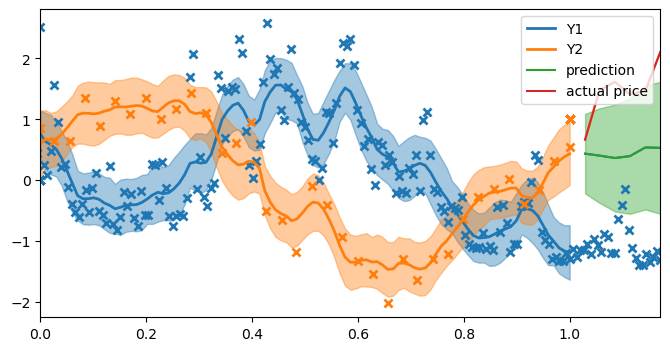

1.1906544886851522


In [30]:
plot(m)
print(m.inducing_variable.Z)
mu, var = m.predict_f(Xtest)
plt.plot(Xtest[:,0], mu)
plt.plot(Xtest[:,0], ytest)
plt.plot(Xtest[:,0], mu, label="prediction")
plt.plot(Xtest[:,0], ytest, label="actual price")
plt.fill_between(
        Xtest[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))